Code to create visualisations, and maybe the dispersion relation of the inertial waves seen in mainly the wide FOV results.

* filtered & reconstructed contours
* frequency vs dispersion relation

Boiler Plate Code here

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm
from scipy.ndimage import gaussian_filter
from scipy.signal import savgol_filter

#####Import Ollie Tools
# dirPath = "C:/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)


####Import Ollie Tools MAC
dirPath = "/Users/olliejackson/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)

oj.thesis_plot_settings()

/Users/olliejackson/Coding
Thesis plot settings applied


time shape
Filter Frequency = 0.3064Hz
Filter Frequency = 0.3064Hz
Filter Frequency = 0.2Hz
Filter Frequency = 0.2828Hz
(3599, 74, 119)


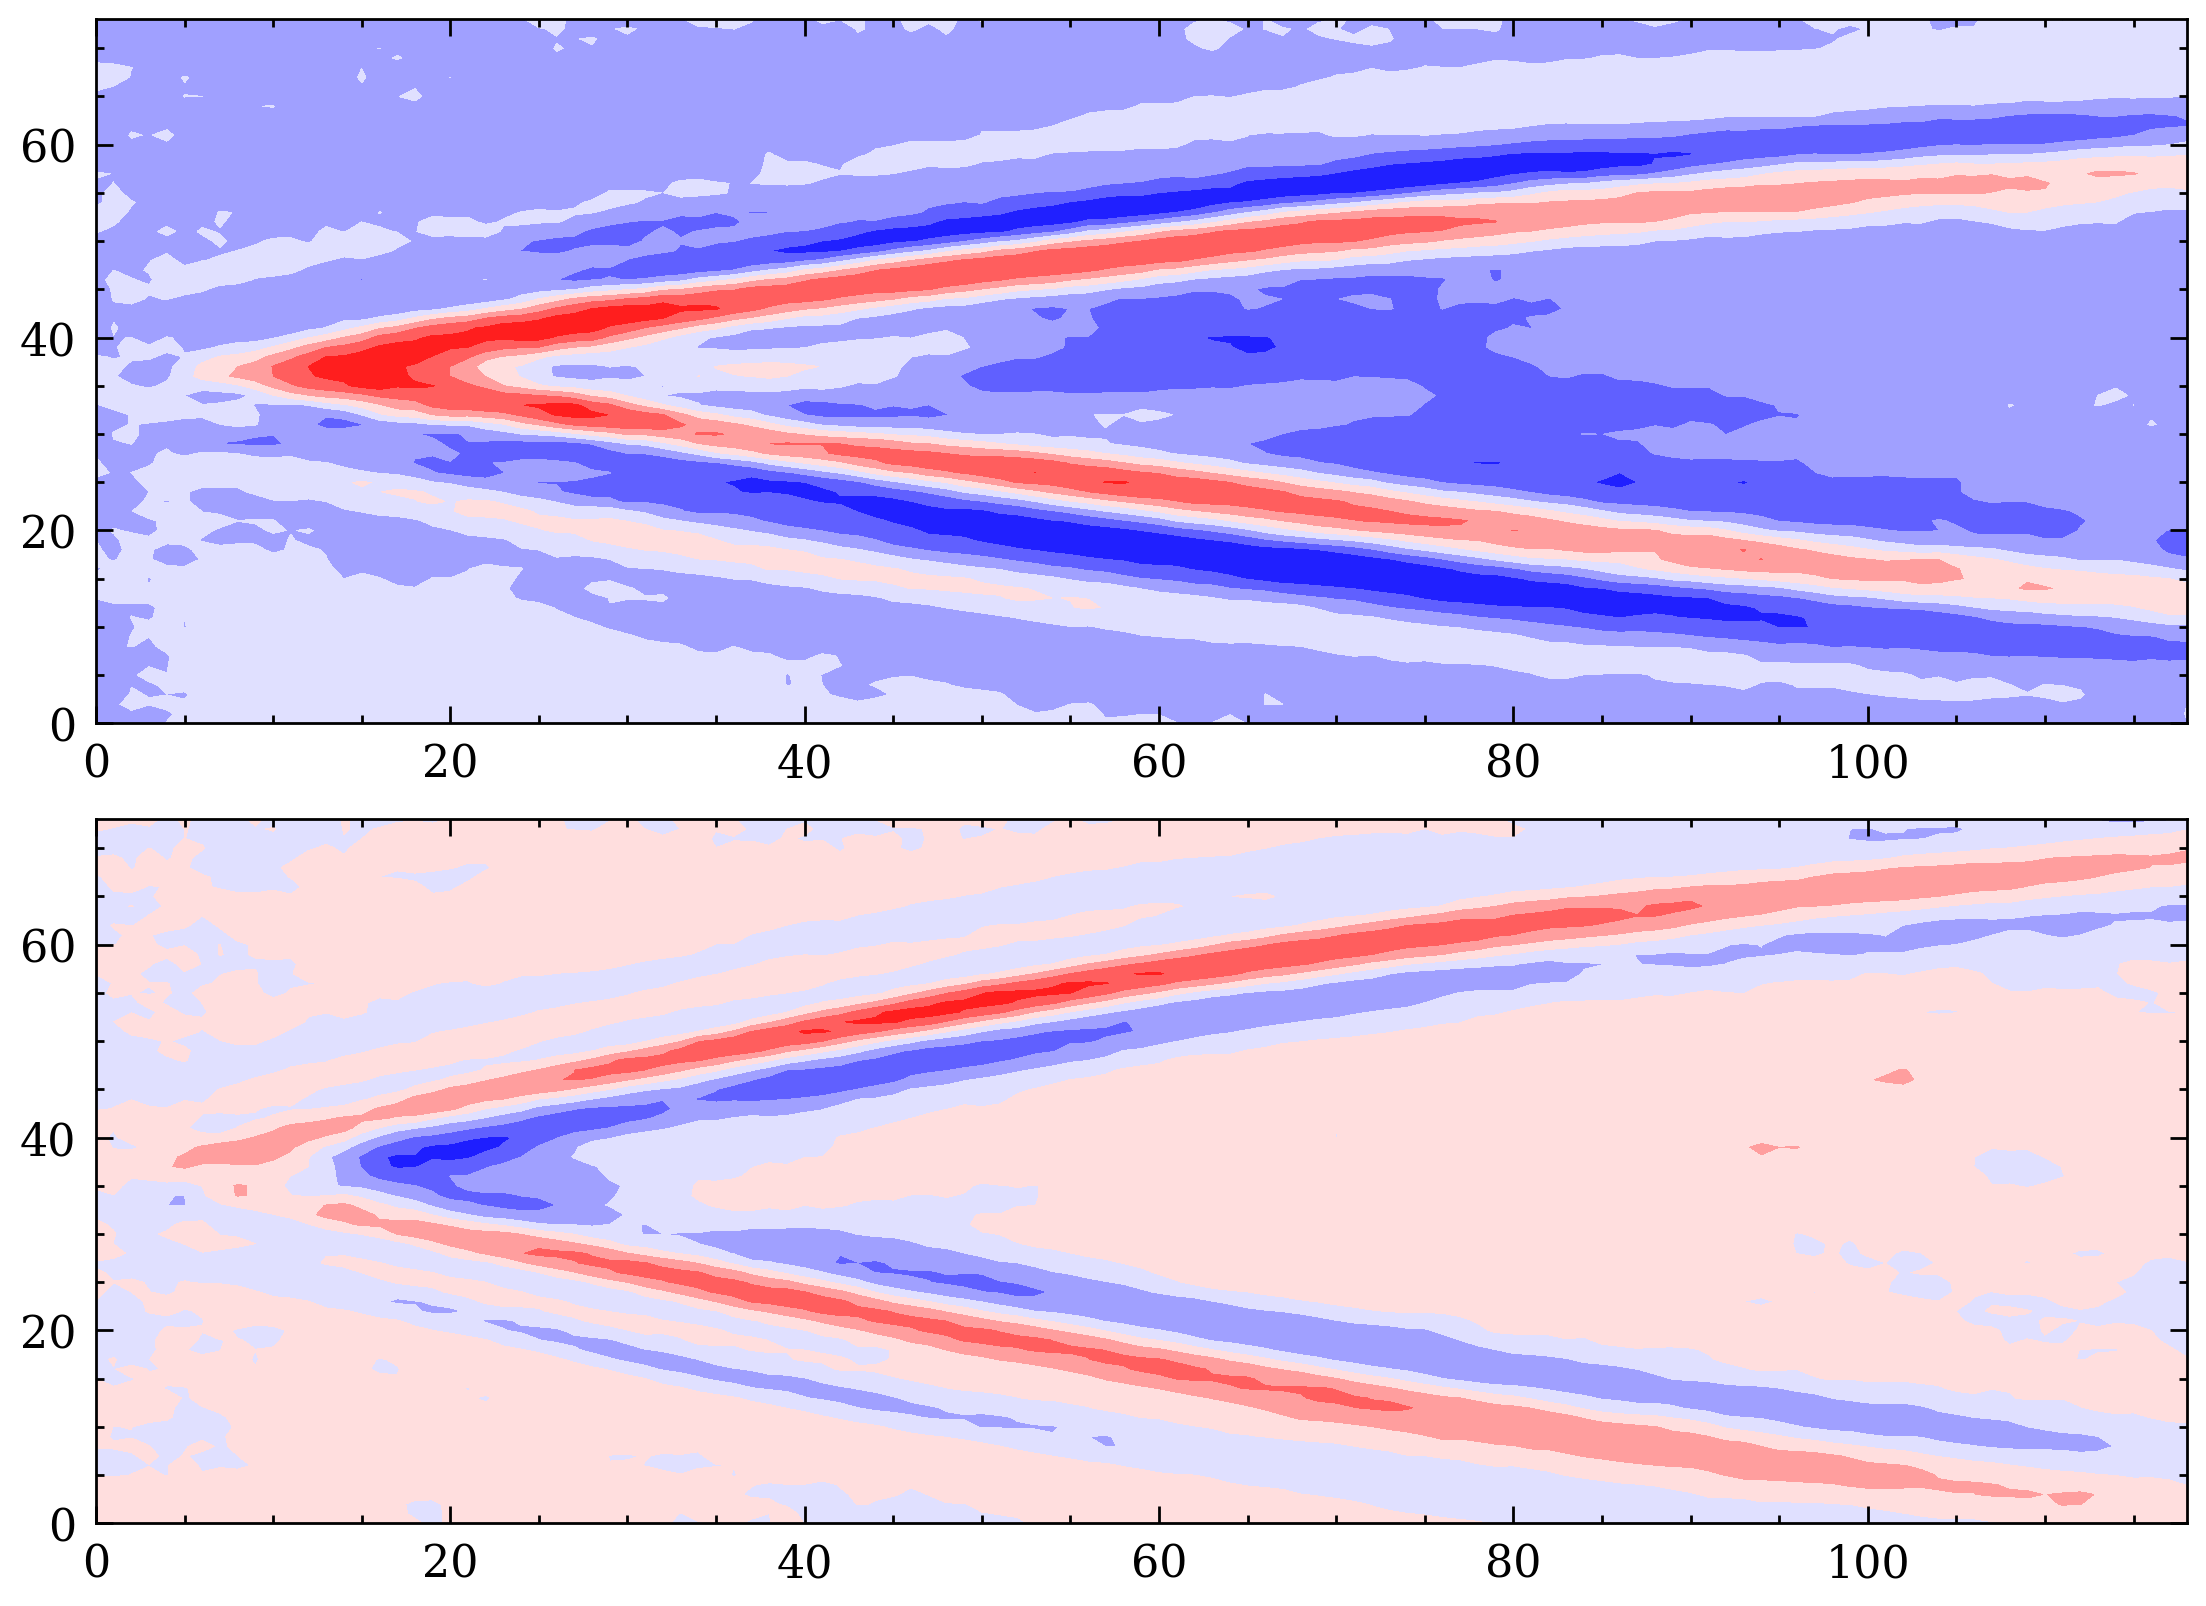

In [7]:
# h5file = h5py.File('E:/H5/3D0meandataHLS.h5', 'r')
# vels = h5file['3D0']['U100']['L100']['RPM12']

# h5file = h5py.File('E:/H5/WideFOV.h5', 'r')
h5file = h5py.File('/Volumes/HLS_0D0/H5/WideFOV.h5', 'r')
vels = h5file['Wide']['U200']['L100']['RPM12']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
h5file.close()
u_gaussian, v_gaussian = gaussian_filter(u, sigma=0.7), gaussian_filter(v, sigma=0.7)
r_nd, z_nd = oj.NDUnitsForPlotsWide(u.shape[1], u.shape[2])

time = oj.frames_to_seconds(u, v, 60)
print("time shape")
# print(time.shape)

#### inertial wave image
vfft_u = oj.IWFilter(u, 40, 60, 12)
vfft_v = oj.IWFilter(v, 40, 60, 12)
# f1, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1)
# ax1.contourf(vfft_u[500,:,:], cmap="bwr")
# ax2.contourf(vfft_v[500,:,:], cmap="bwr")
# plt.show()


vfft_u  = oj.IWFilter(u, 60, 150, 12)
vfft_u2 = oj.IWFilter(u, 45, 150, 12)
print(vfft_u.shape)
f2, (ax1, ax2) = plt.subplots(nrows = 2, ncols = 1)
ax1.contourf(vfft_u [1500,:,:], cmap="bwr")
ax2.contourf(vfft_u2[1500,:,:], cmap="bwr")
plt.show()

# vfft_u = oj.IWFilter(u, 45, 60, 6)
# f2, ax1 = plt.subplots(nrows = 1, ncols = 1)
# ax1.contourf(vfft_u[500,:,:], cmap="bwr")
# plt.show()

Creating a proper series of plots.

These will be created individually and then put together in Latex

(3599, 74, 119)
Filter Frequency = 0.169Hz


posx and posy should be finite values


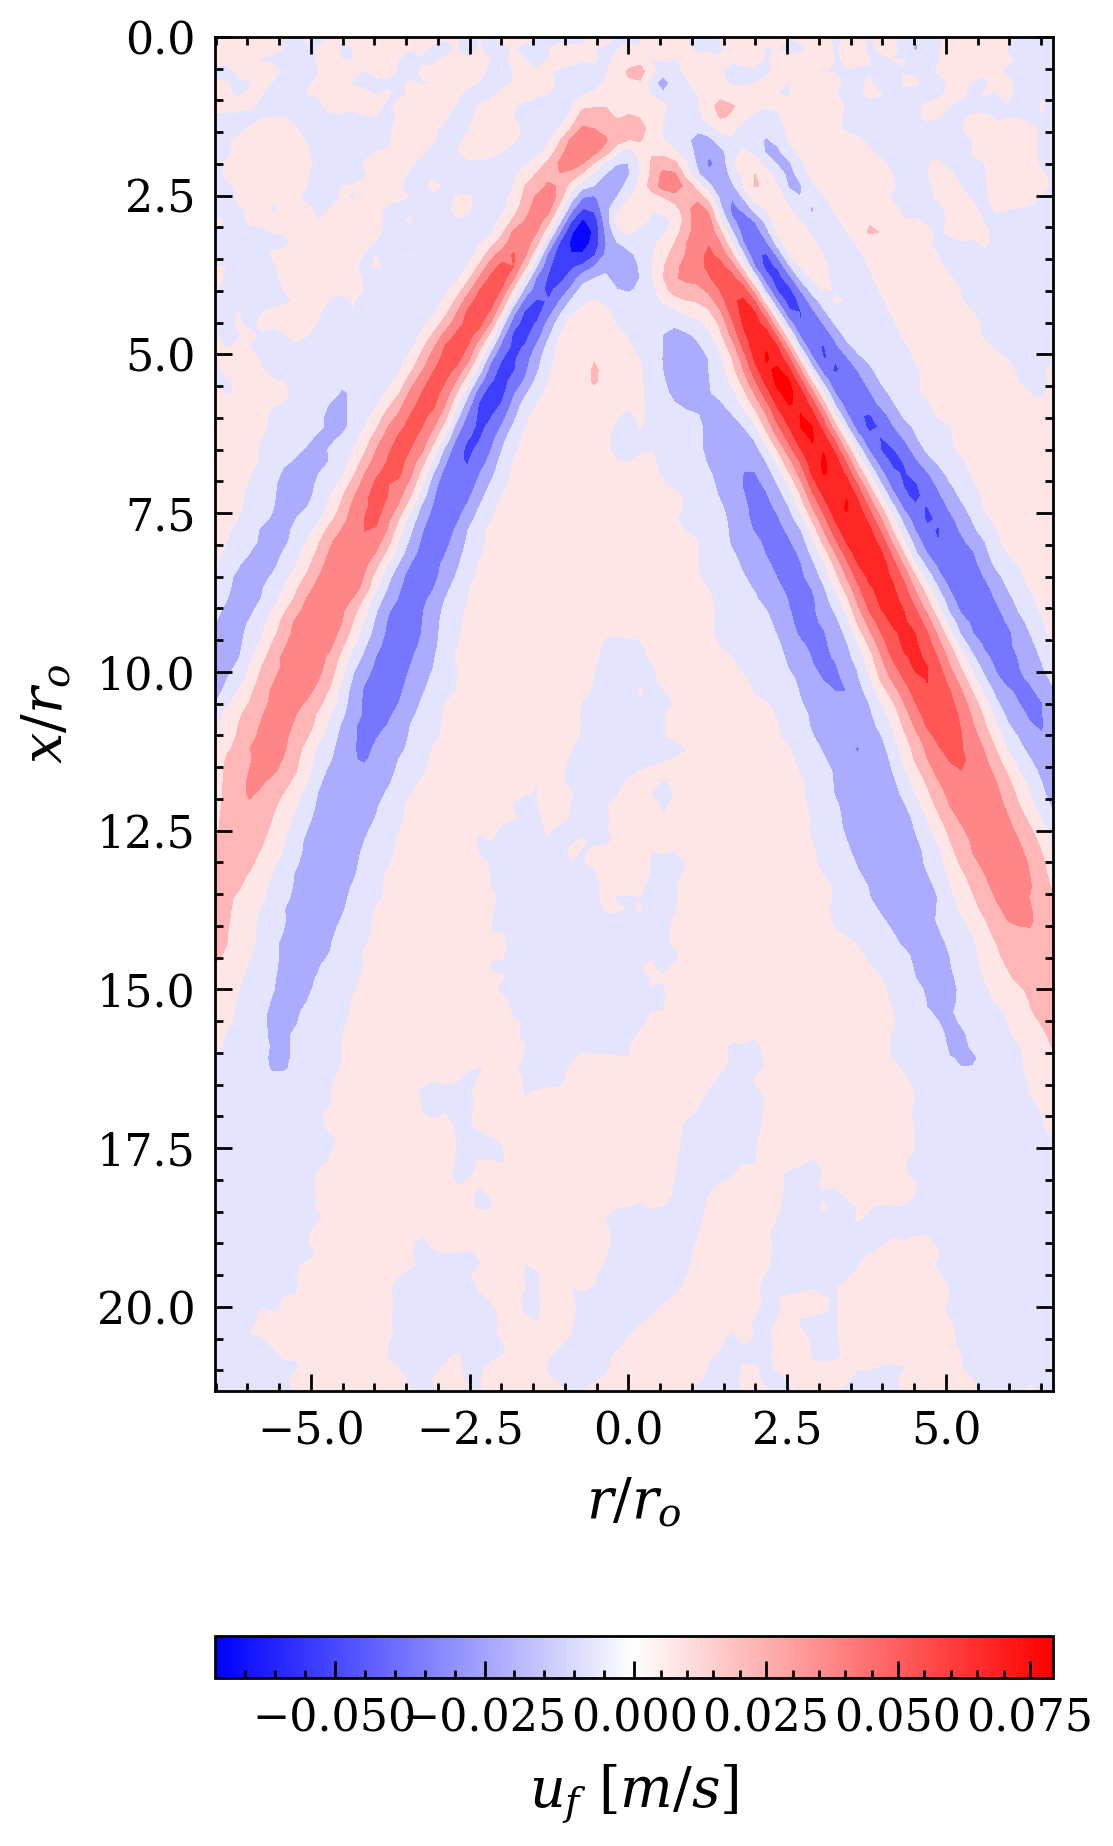

In [63]:
frame = 600

rpm = 12
fps = 60
angle = 90-25
print(u.shape)
u_swapped = np.transpose(u, (0, 2, 1))
# print(u_swapped.shape)
Z_rotated = np.flipud(np.fliplr(vfft_u[frame, :, :]))

vfft_u  = oj.IWFilter(v, angle, fps, rpm)

norm = colors.TwoSlopeNorm(vmin=np.min(vfft_u[frame, :, :]), vcenter=0, vmax=np.max(vfft_u[frame, :, :]))
f1, ax = plt.subplots(1, 1, figsize=(8/3, 5.5), layout='constrained')
plt.gca().set_aspect('equal')
ax.set_ylim(z_nd.max(), z_nd.min())
# ax = f1.add_subplot(2,1,1, adjustable='box', aspect=1)
ax.contourf(r_nd, z_nd, np.rot90(vfft_u[frame, :, :], 3), norm=norm, cmap='bwr', levels=10)
# ax.contourf(np.rot90(vfft_u[frame, :, :], 3), norm=norm, cmap='bwr', levels=10)
# ax.contourf(u_swapped[frame, :, :], norm=norm, cmap='bwr', levels=10)
ax.set_xlabel(r"$r/r_{o}$")
ax.set_ylabel(r"$x/r_{o}$")
f1.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='bwr'), ax=ax, label=r'$u_{f} ~[m/s]$', location='bottom')

AttributeError: 'NoneType' object has no attribute 'get_subplotspec'

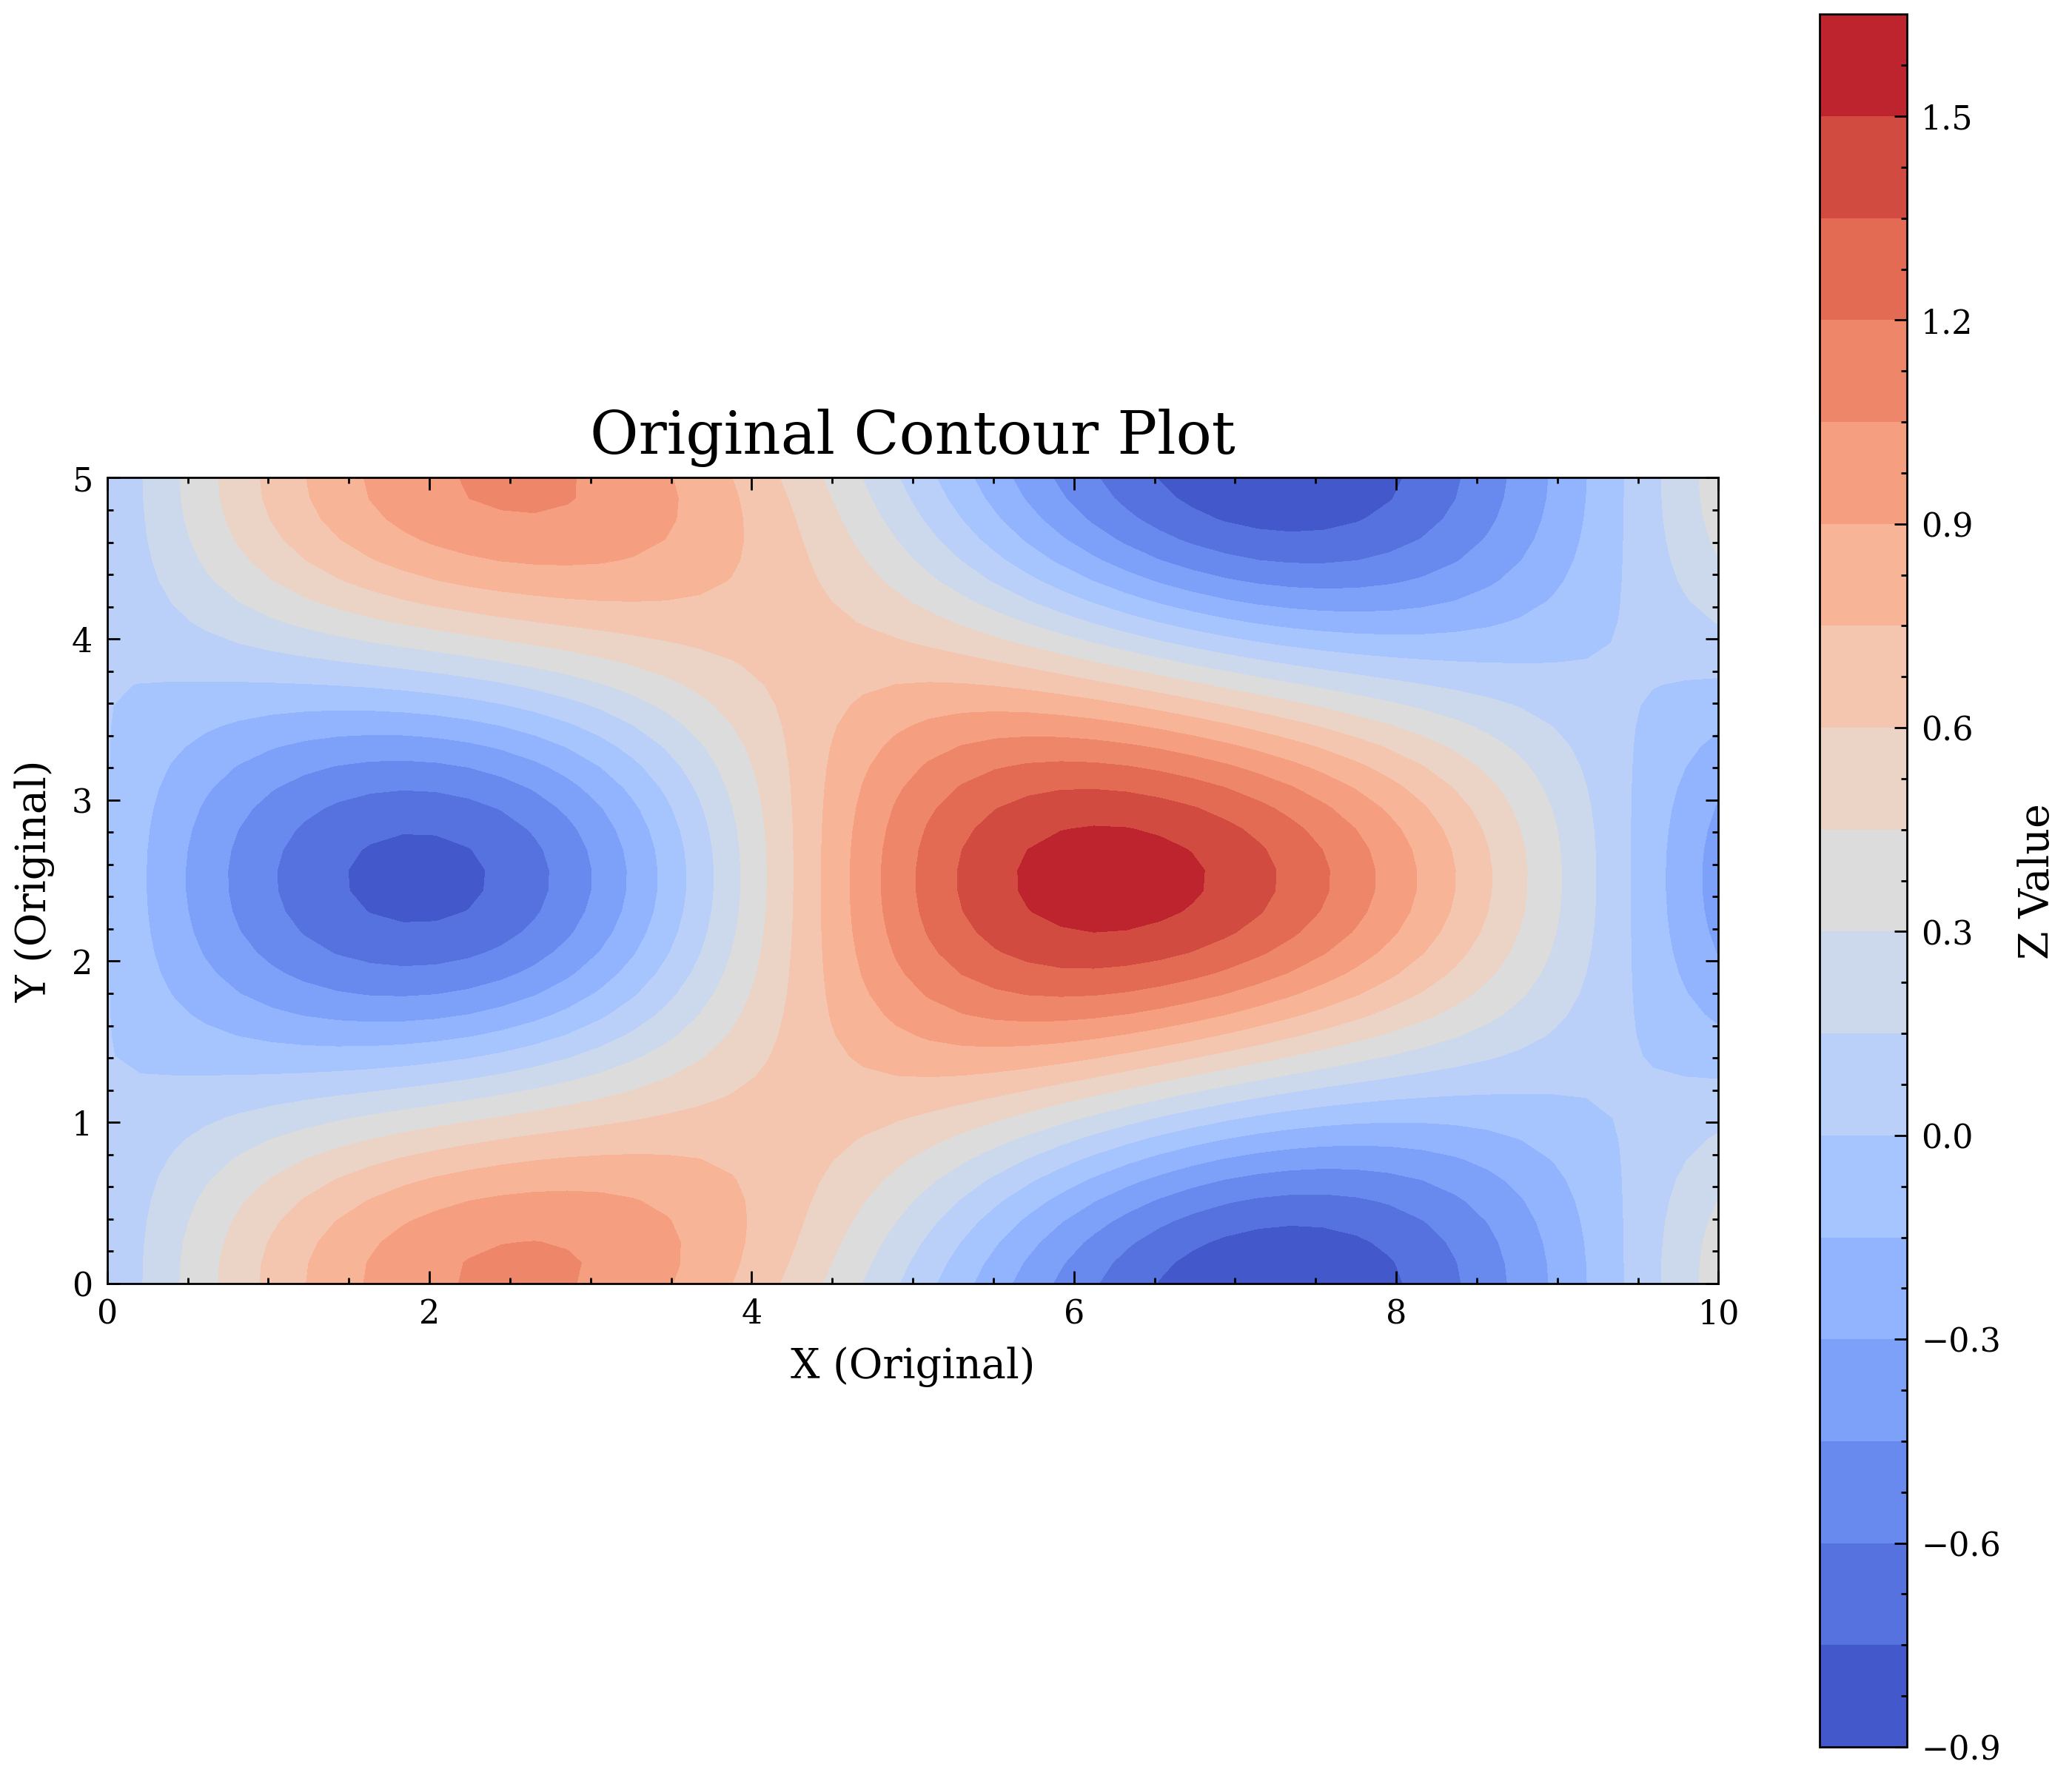

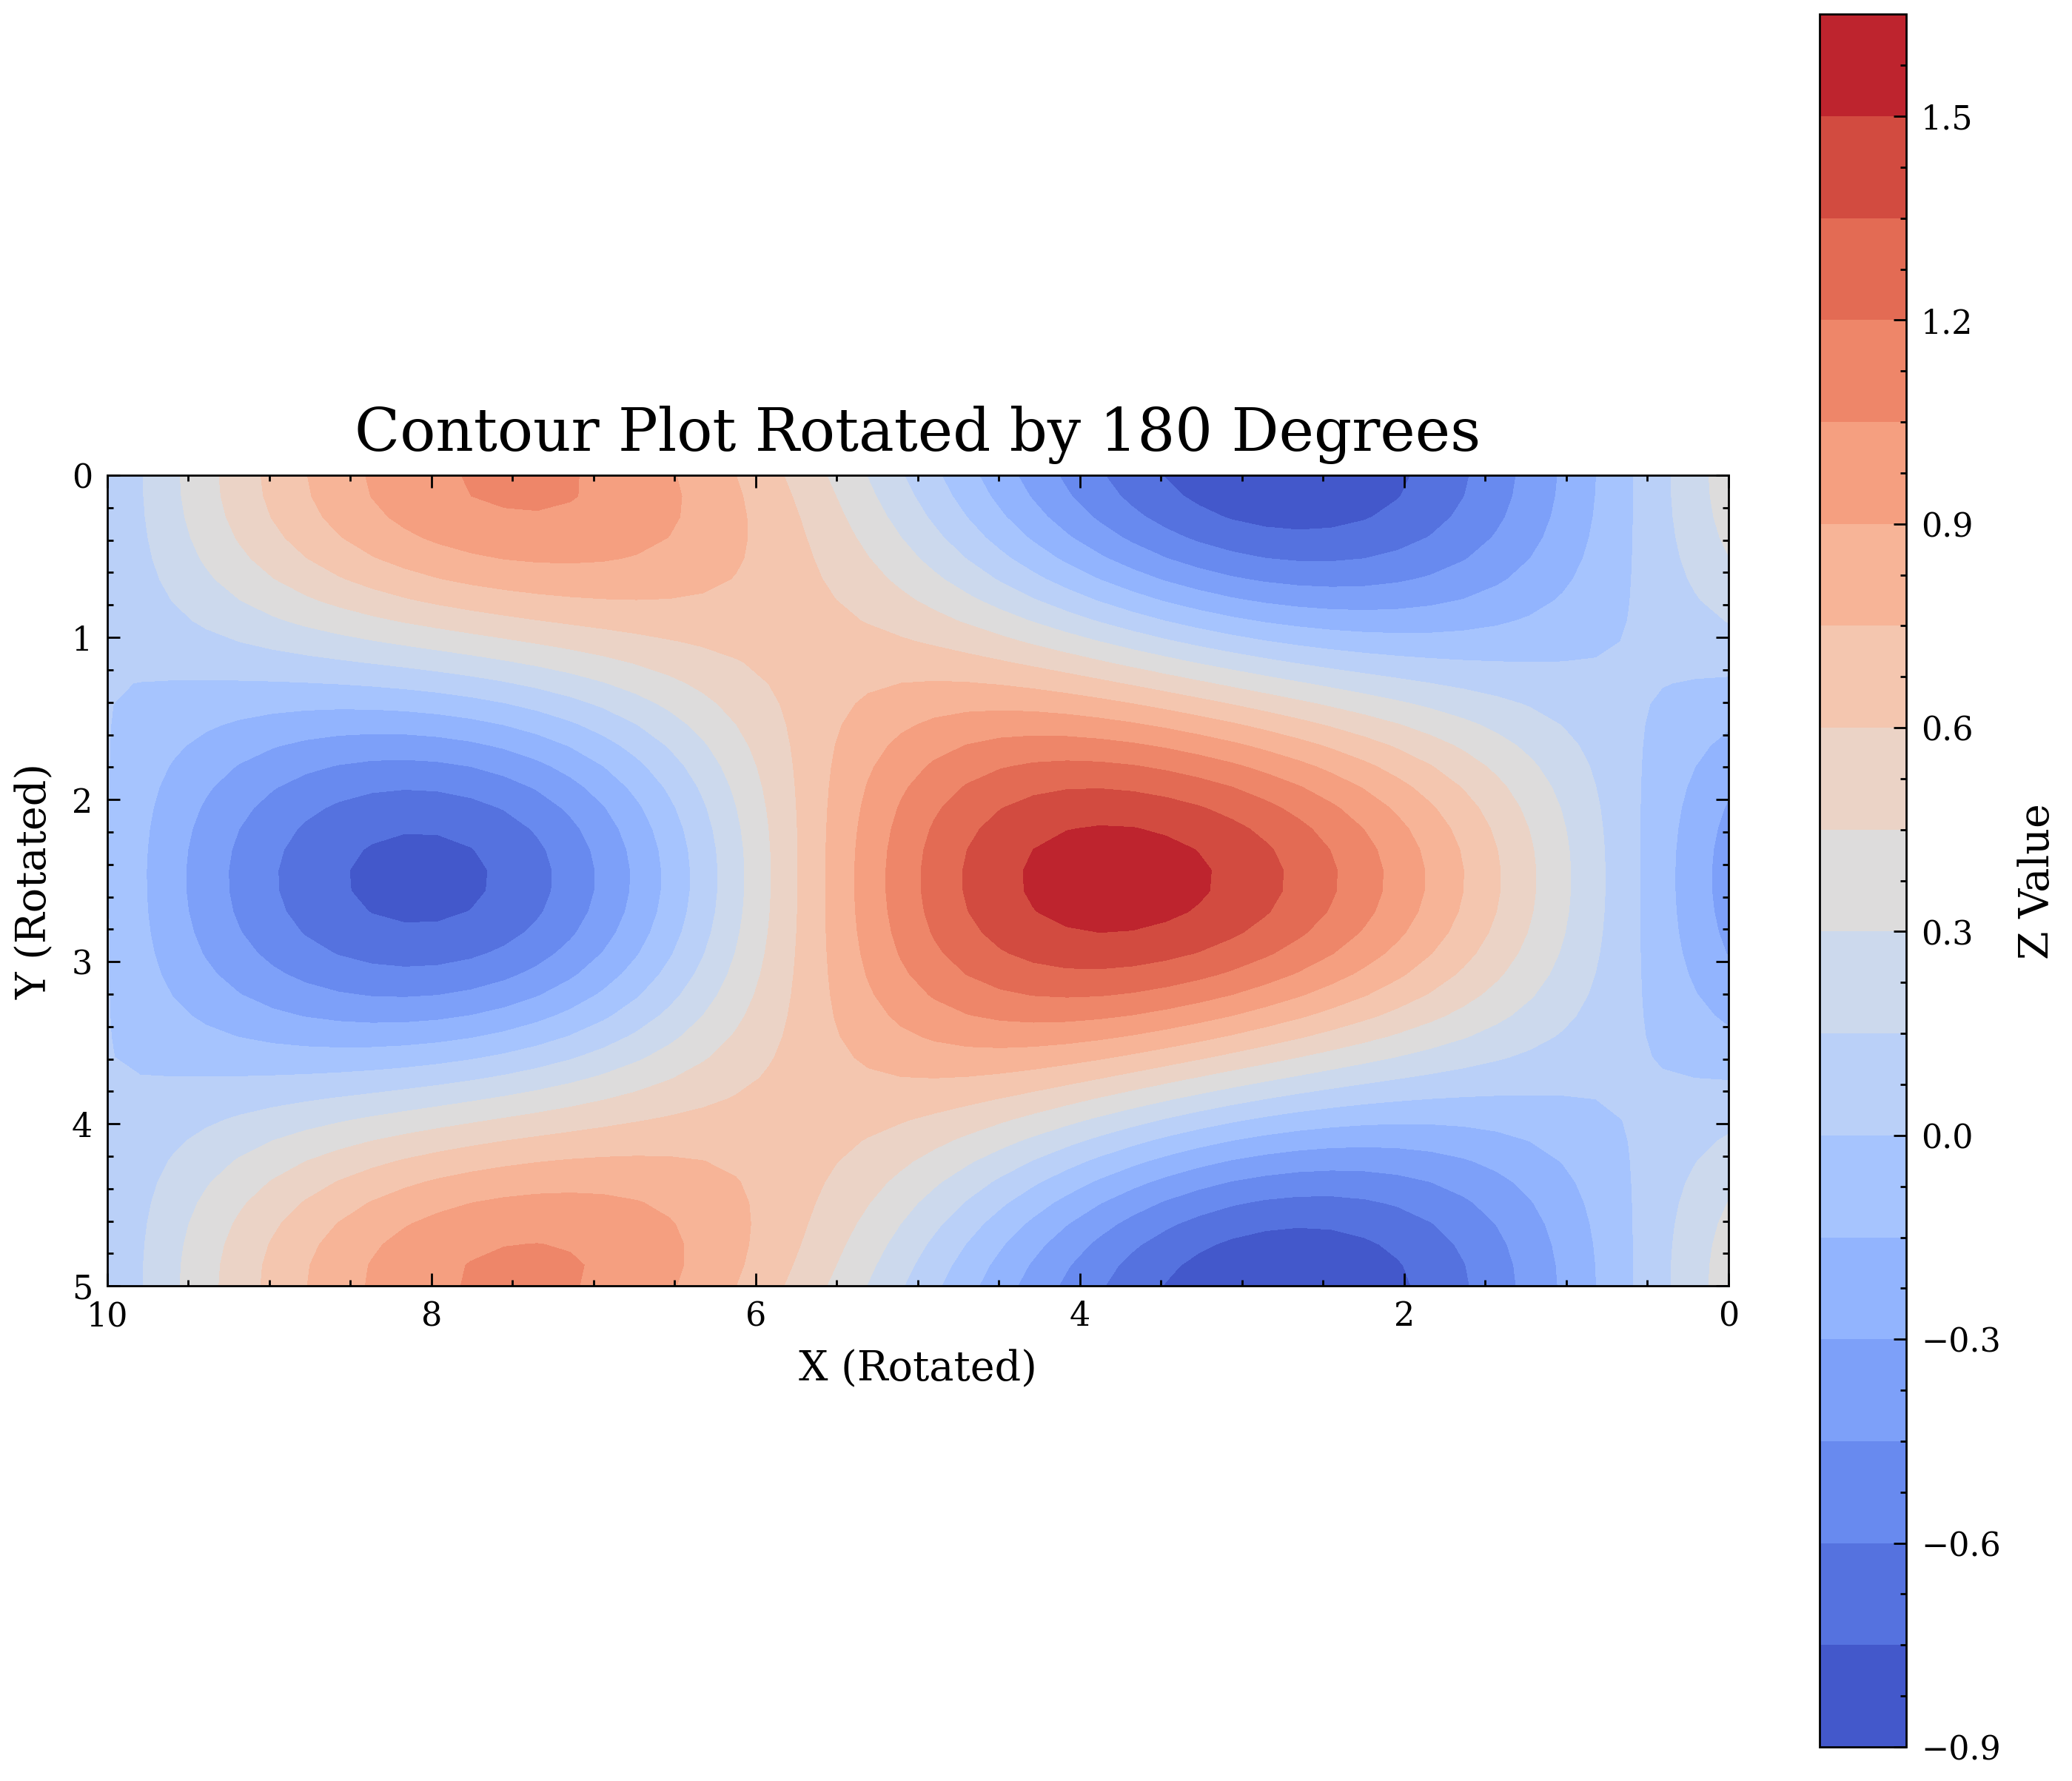

In [33]:
# 1. Define your original data
# Let's create some sample data representing a contour
x_orig = np.linspace(0, 10, 50)
y_orig = np.linspace(0, 5, 40)
X_orig, Y_orig = np.meshgrid(x_orig, y_orig)
Z_orig = np.sin(X_orig / 1.5) * np.cos(Y_orig / 0.8) + np.exp(-( (X_orig-5)**2 + (Y_orig-2.5)**2 ) / 5) # Example Z data

# --- Original Plot ---
fig1, ax1 = plt.subplots(figsize=(7, 6))
contour1 = ax1.contourf(x_orig, y_orig, Z_orig, levels=20, cmap='coolwarm')
fig1.colorbar(contour1, ax=ax1, label='Z Value')
ax1.set_xlabel('X (Original)')
ax1.set_ylabel('Y (Original)')
ax1.set_title('Original Contour Plot')
ax1.set_aspect('equal') # Keep aspect ratio for better visualization of rotation

# --- 180 Degree Rotated Plot ---
fig2, ax2 = plt.subplots(figsize=(7, 6))

# Apply the transformations to the data
# 1. Flip Z data: first flip up/down, then left/right
# This effectively rotates the Z data by 180 degrees
Z_rotated = np.flipud(np.fliplr(Z_orig))

# Now create the contour plot with the *original* x and y arrays
# but using the *rotated* Z data
contour2 = ax2.contourf(x_orig, y_orig, Z_rotated, levels=20, cmap='coolwarm')
fig2.colorbar(contour2, ax=ax2, label='Z Value')

# Reverse both X and Y axes
ax2.set_xlim(x_orig.max(), x_orig.min()) # Reverse X axis
ax2.set_ylim(y_orig.max(), y_orig.min()) # Reverse Y axis

ax2.set_xlabel('X (Rotated)')
ax2.set_ylabel('Y (Rotated)')
ax2.set_title('Contour Plot Rotated by 180 Degrees')
ax2.set_aspect('equal') # Keep aspect ratio

plt.tight_layout()
plt.show()